# Predictive Modeling — Obesity Level Classification
###Data Analytics Final Project — Machine Learning Section

**Dataset:** `obesity_Visualization_dataClean.csv` (2,090 rows, 17 columns)

**Target variable:** `NObeyesdad` — 7 obesity level classes (Insufficient_Weight, Normal_Weight, Overweight_Level_I/II, Obesity_Type_I/II/III)

**This notebook covers the *Data Cleaning* and *Predictive Modeling* deliverables :**
- Outlier detection & treatment using statistical methods (IQR)
- Prediction of a target variable
- Logistic Regression, Decision Tree, Random Forest, SVM (classification models)
- Linear Regression (regression model, used here to predict `Weight` as a continuous target)
- Evaluation using accuracy and confusion matrix
- AI-generated natural-language insights & business-oriented recommendations


## 1. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, confusion_matrix, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
RANDOM_STATE = 42

pd.set_option("display.max_columns", None)


## 2. Load Data

In [2]:
df = pd.read_csv("obesity_Visualization_dataClean.csv")
print(df.shape)
df.head()


(2090, 17)


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad
0,Male,35,1.71,84.72,yes,yes,2.880000,3.0,Sometimes,no,3.00,no,2.00,0.832,no,Automobile,Overweight_Level_II
1,Male,19,1.75,100.00,yes,yes,2.000000,3.0,Frequently,no,2.00,no,2.00,0.000,no,Public_Transportation,Obesity_Type_I
2,Male,19,1.85,65.00,yes,no,2.000000,3.0,Sometimes,no,3.00,no,2.00,1.000,Sometimes,Bike,Normal_Weight
3,Male,31,1.78,120.64,yes,yes,2.408579,3.0,Sometimes,no,2.04,no,0.84,0.490,Sometimes,Automobile,Obesity_Type_II
4,Male,25,1.80,120.90,yes,yes,2.408579,3.0,Sometimes,no,2.51,no,1.66,0.128,Sometimes,Public_Transportation,Obesity_Type_II


In [3]:
# Confirm the dataset is already clean (no missing values, correct dtypes)
print("Missing values per column:")
print(df.isna().sum())
print("\nDuplicate rows:", df.duplicated().sum())


Missing values per column:
Gender                            0
Age                               0
Height                            0
Weight                            0
family_history_with_overweight    0
FAVC                              0
FCVC                              0
NCP                               0
CAEC                              0
SMOKE                             0
CH2O                              0
SCC                               0
FAF                               0
TUE                               0
CALC                              0
MTRANS                            0
NObeyesdad                        0
dtype: int64

Duplicate rows: 0


## 3. Outlier Detection & Treatment

**Detecting and treating outliers using statistical methods** as part of cleaning. Even though the CSV was pre-cleaned (no missing values), it has not been checked for outliers yet — that's done here, on the continuous numeric columns: `Age`, `Height`, `Weight`, `FCVC`, `NCP`, `CH2O`, `FAF`, `TUE`.


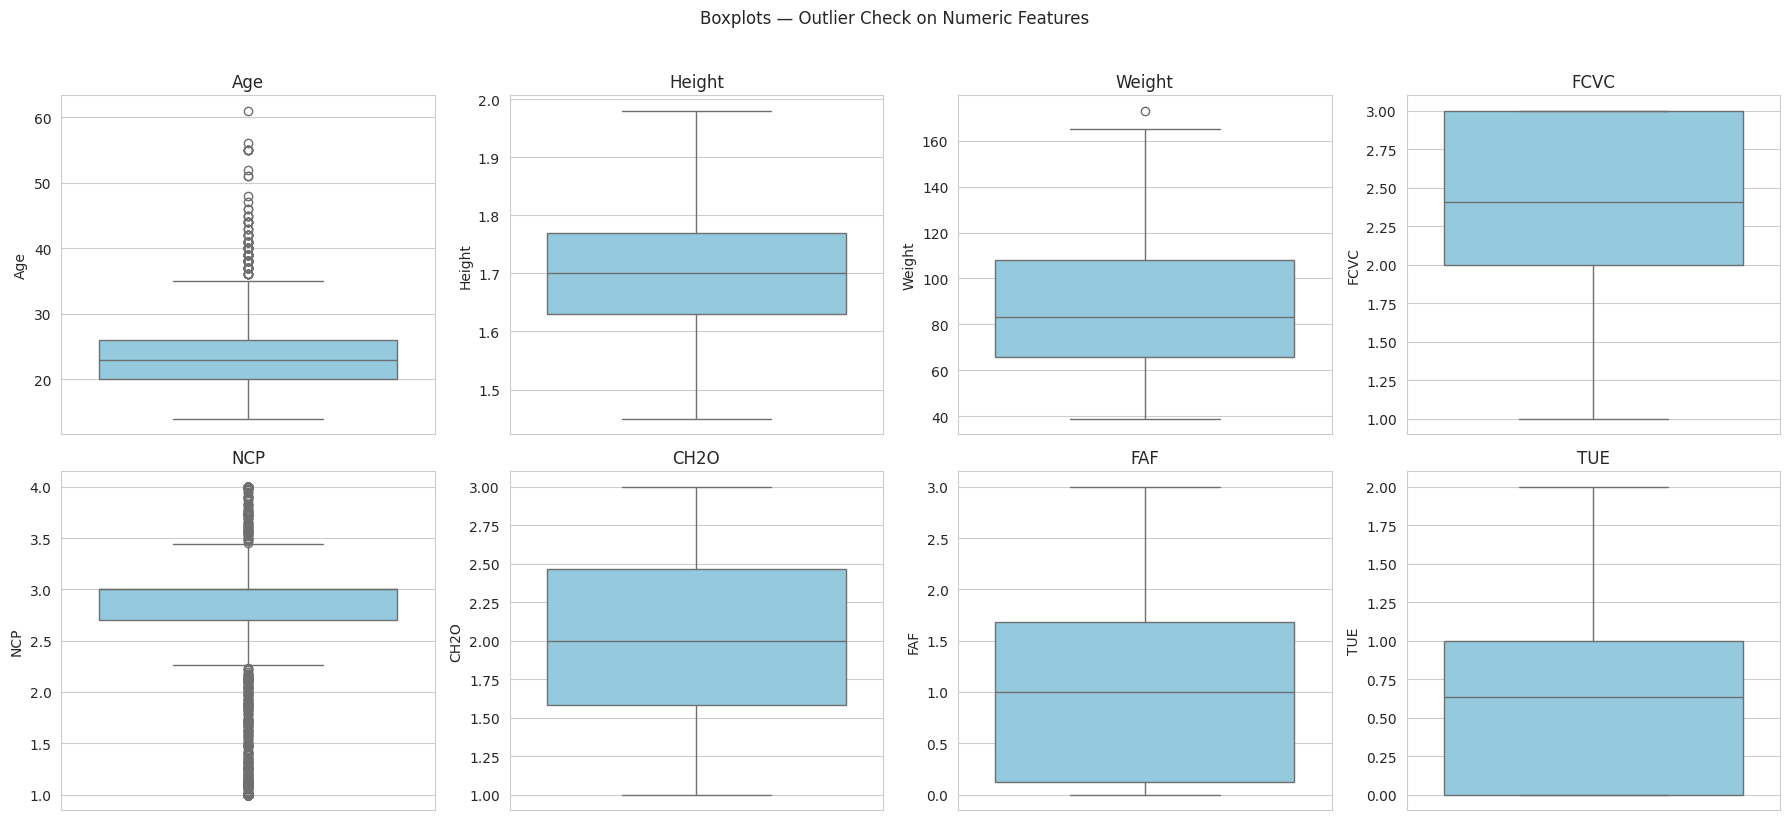

In [8]:
num_cols = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.suptitle("Boxplots — Outlier Check on Numeric Features", y=1.02)
plt.tight_layout()
plt.show()



### Interpretation before treating

- **`Age`** is naturally right-skewed (most respondents are 14–26, with a long tail to 61). The IQR rule over-flags the tail of a skewed-but-legitimate distribution — these are real adult ages, not data-entry errors.
- **`NCP`** (number of main meals) has 256 distinct *fractional* values (e.g. 1.13, 2.71) instead of clean integers 1–4 — a clear signature of synthetic interpolation between real survey responses, not measurement error.

Blindly deleting every flagged row would remove ~28% of the data (mostly for `NCP` alone) and throw away legitimate signal. Instead, a **more conservative "extreme outlier" rule (3×IQR)** is applied, and only points beyond that are treated (capped), which targets genuinely extreme/implausible values while preserving natural distribution shape.


In [9]:
def iqr_bounds_extreme(series, k=3.0):
    q1, q3 = series.quantile(0.25), series.quantile(0.75)
    iqr = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

extreme_report = []
for col in num_cols:
    low, high = iqr_bounds_extreme(df[col], k=3.0)
    n_out = ((df[col] < low) | (df[col] > high)).sum()
    extreme_report.append({"Column": col, "Lower bound": round(low, 2),
                            "Upper bound": round(high, 2),
                            "Extreme outliers (3xIQR)": n_out})

extreme_df = pd.DataFrame(extreme_report)
extreme_df


,Column,Lower bound,Upper bound,Extreme outliers (3xIQR)
0,Age,2.00,44.00,17
1,Height,1.21,2.19,0
2,Weight,-60.29,234.23,0
3,FCVC,-1.00,6.00,0
4,NCP,1.80,3.90,433
5,CH2O,-1.07,5.12,0
6,FAF,-4.54,6.34,0
7,TUE,-3.00,4.00,0


In [10]:
#cap only the genuinely extreme values
df_treated = df.copy()
treatment_log = {}

for col in num_cols:
    low, high = iqr_bounds_extreme(df_treated[col], k=3.0)
    n_capped_low = (df_treated[col] < low).sum()
    n_capped_high = (df_treated[col] > high).sum()
    df_treated[col] = df_treated[col].clip(lower=low, upper=high)
    if n_capped_low or n_capped_high:
        treatment_log[col] = {"capped_low": int(n_capped_low), "capped_high": int(n_capped_high)}

print("Values capped (winsorized) at the 3xIQR extreme-outlier bounds:")
for col, log in treatment_log.items():
    print(f"  {col}: {log['capped_low']} capped low, {log['capped_high']} capped high")
if not treatment_log:
    print("  None — no values fell beyond the extreme (3xIQR) bounds.")


Values capped (winsorized) at the 3xIQR extreme-outlier bounds:
  Age: 0 capped low, 17 capped high
  NCP: 342 capped low, 91 capped high


**Decision:** use `df_treated` going forward — no rows were dropped , only truly extreme values were capped at the 3×IQR bounds. Respecting that most of the "IQR-flagged" spread in `Age` and `NCP` reflects genuine/synthetic distribution shape rather than data errors.


## 4. Feature Engineering & Preprocessing

- **Categorical binary columns** (`Gender`, `family_history_with_overweight`, `FAVC`, `SMOKE`, `SCC`) → label-encoded (0/1)
- **Ordinal-ish categorical columns** (`CAEC`, `CALC`) → encoded with a meaningful order (no < Sometimes < Frequently < Always)
- **Nominal column** (`MTRANS`) → one-hot encoded
- **Target** (`NObeyesdad`) → label-encoded for the classifiers, but we keep the class names for readable reports
- A simple engineered feature, **BMI** (`Weight / Height^2`), is added since it is the clinical basis for the target label and should give the tree-based models an easy, interpretable signal


In [11]:
data = df_treated.copy()

# Engineered feature: BMI
data["BMI"] = data["Weight"] / (data["Height"] ** 2)

# mapping no->0 , yes->1
binary_map = {"yes": 1, "no": 0}
for col in ["family_history_with_overweight", "FAVC", "SMOKE", "SCC"]:
    data[col] = data[col].map(binary_map)

# mapping Female->0 , Male->1
data["Gender"] = data["Gender"].map({"Male": 1, "Female": 0})

# Ordinal encode CAEC / CALC
freq_order = {"no": 0, "Sometimes": 1, "Frequently": 2, "Always": 3}
data["CAEC"] = data["CAEC"].map(freq_order)
data["CALC"] = data["CALC"].map(freq_order)

# One-hot encode nominal MTRANS
data = pd.get_dummies(data, columns=["MTRANS"], prefix="MTRANS", drop_first=True)

# Encode target
target_le = LabelEncoder()
data["NObeyesdad_enc"] = target_le.fit_transform(data["NObeyesdad"])
class_names = target_le.classes_

data.head()


,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,NObeyesdad,BMI,MTRANS_Bike,MTRANS_Motorbike,MTRANS_Public_Transportation,MTRANS_Walking,NObeyesdad_enc
0,1,35,1.71,84.72,1,1,2.880000,3.0,1,0,3.00,0,2.00,0.832,0,Overweight_Level_II,28.973017,False,False,False,False,6
1,1,19,1.75,100.00,1,1,2.000000,3.0,2,0,2.00,0,2.00,0.000,0,Obesity_Type_I,32.653061,False,False,True,False,2
2,1,19,1.85,65.00,1,0,2.000000,3.0,1,0,3.00,0,2.00,1.000,1,Normal_Weight,18.991965,True,False,False,False,1
3,1,31,1.78,120.64,1,1,2.408579,3.0,1,0,2.04,0,0.84,0.490,1,Obesity_Type_II,38.076001,False,False,False,False,3
4,1,25,1.80,120.90,1,1,2.408579,3.0,1,0,2.51,0,1.66,0.128,1,Obesity_Type_II,37.314815,False,False,True,False,3


## 5. Exploratory Check on the Target

/tmp/ipykernel_2463/3299205291.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y="NObeyesdad", data=df, order=order, palette="Blues")


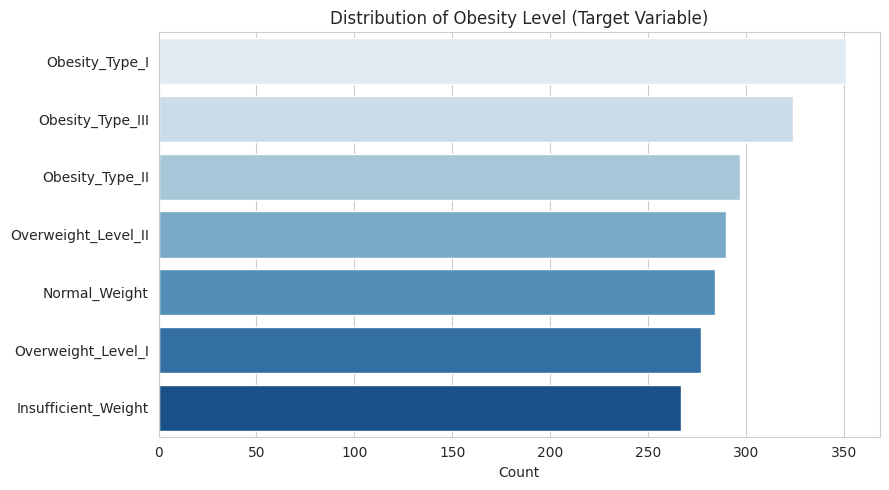

In [12]:
plt.figure(figsize=(9, 5))
order = df["NObeyesdad"].value_counts().index
sns.countplot(y="NObeyesdad", data=df, order=order, palette="Blues")
plt.title("Distribution of Obesity Level (Target Variable)")
plt.xlabel("Count")
plt.ylabel("")
plt.tight_layout()
plt.show()


## 5. Classification Models

We predict `NObeyesdad` (7 classes) using:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine (SVM)

An 80/20 train-test split is used, stratified on the target to preserve class balance. Numeric features are standardized for the models that are scale-sensitive (Logistic Regression, SVM); Decision Tree and Random Forest are scale-invariant but we reuse the same scaled matrix for consistency.


In [13]:
feature_cols = [c for c in data.columns if c not in ["NObeyesdad", "NObeyesdad_enc"]]
X = data[feature_cols]
y = data["NObeyesdad_enc"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (1672, 20)  Test shape: (418, 20)


In [14]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    acc = accuracy_score(y_te, preds)
    results[name] = {"model": model, "preds": preds, "accuracy": acc}
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_te, preds, target_names=class_names, zero_division=0))
    return preds


In [15]:
# 1. Logistic Regression
log_reg = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
_ = evaluate_model("Logistic Regression", log_reg, X_train_scaled, y_train, X_test_scaled, y_test)


--- Logistic Regression ---
Accuracy: 0.9187
                     precision    recall  f1-score   support

Insufficient_Weight       0.95      0.98      0.96        53
      Normal_Weight       0.91      0.84      0.87        57
     Obesity_Type_I       0.94      0.97      0.96        70
    Obesity_Type_II       0.97      0.98      0.98        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.79      0.82      0.80        55
Overweight_Level_II       0.86      0.83      0.84        58

           accuracy                           0.92       418
          macro avg       0.92      0.92      0.92       418
       weighted avg       0.92      0.92      0.92       418



In [16]:
# 2. Decision Tree
dt = DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE)
_ = evaluate_model("Decision Tree", dt, X_train, y_train, X_test, y_test)


--- Decision Tree ---
Accuracy: 0.9737
                     precision    recall  f1-score   support

Insufficient_Weight       0.98      0.98      0.98        53
      Normal_Weight       0.95      0.95      0.95        57
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       0.90      0.95      0.92        55
Overweight_Level_II       0.98      0.93      0.96        58

           accuracy                           0.97       418
          macro avg       0.97      0.97      0.97       418
       weighted avg       0.97      0.97      0.97       418



In [17]:
# 3. Random Forest
rf = RandomForestClassifier(n_estimators=300, max_depth=12, random_state=RANDOM_STATE)
_ = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)


--- Random Forest ---
Accuracy: 0.9976
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        53
      Normal_Weight       0.98      1.00      0.99        57
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       1.00      1.00      1.00        60
   Obesity_Type_III       1.00      1.00      1.00        65
 Overweight_Level_I       1.00      1.00      1.00        55
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           1.00       418
          macro avg       1.00      1.00      1.00       418
       weighted avg       1.00      1.00      1.00       418



In [19]:
# 4. SVM
svm = SVC(kernel="rbf", C=5, gamma="scale", random_state=RANDOM_STATE)
_ = evaluate_model("SVM", svm, X_train_scaled, y_train, X_test_scaled, y_test)


--- SVM ---
Accuracy: 0.9426
                     precision    recall  f1-score   support

Insufficient_Weight       0.91      1.00      0.95        53
      Normal_Weight       0.88      0.77      0.82        57
     Obesity_Type_I       0.95      1.00      0.97        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.87      0.87      0.87        55
Overweight_Level_II       0.98      0.95      0.96        58

           accuracy                           0.94       418
          macro avg       0.94      0.94      0.94       418
       weighted avg       0.94      0.94      0.94       418



## 6. Model Comparison

In [20]:
acc_df = pd.DataFrame({
    "Model": list(results.keys()),
    "Accuracy": [results[m]["accuracy"] for m in results]
}).sort_values("Accuracy", ascending=False).reset_index(drop=True)

acc_df


,Model,Accuracy
0,Random Forest,0.997608
1,Decision Tree,0.973684
2,SVM,0.942584
3,Logistic Regression,0.918660


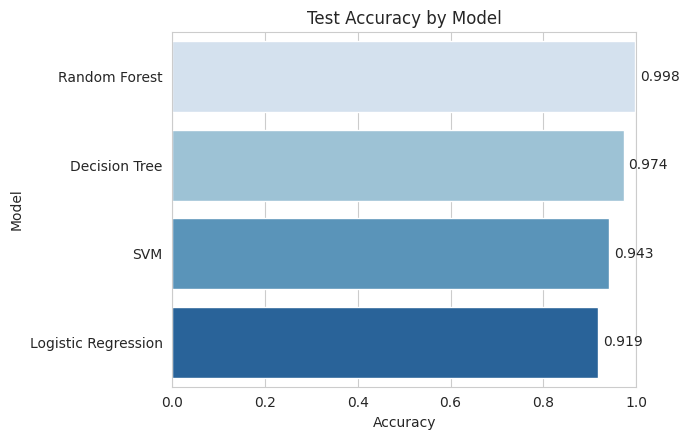

In [22]:
plt.figure(figsize=(7, 4.5))
sns.barplot(data=acc_df, x="Accuracy", y="Model", hue="Model", palette="Blues", legend=False)
plt.xlim(0, 1)
for i, v in enumerate(acc_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.title("Test Accuracy by Model")
plt.tight_layout()
plt.show()


## 7. Confusion Matrices

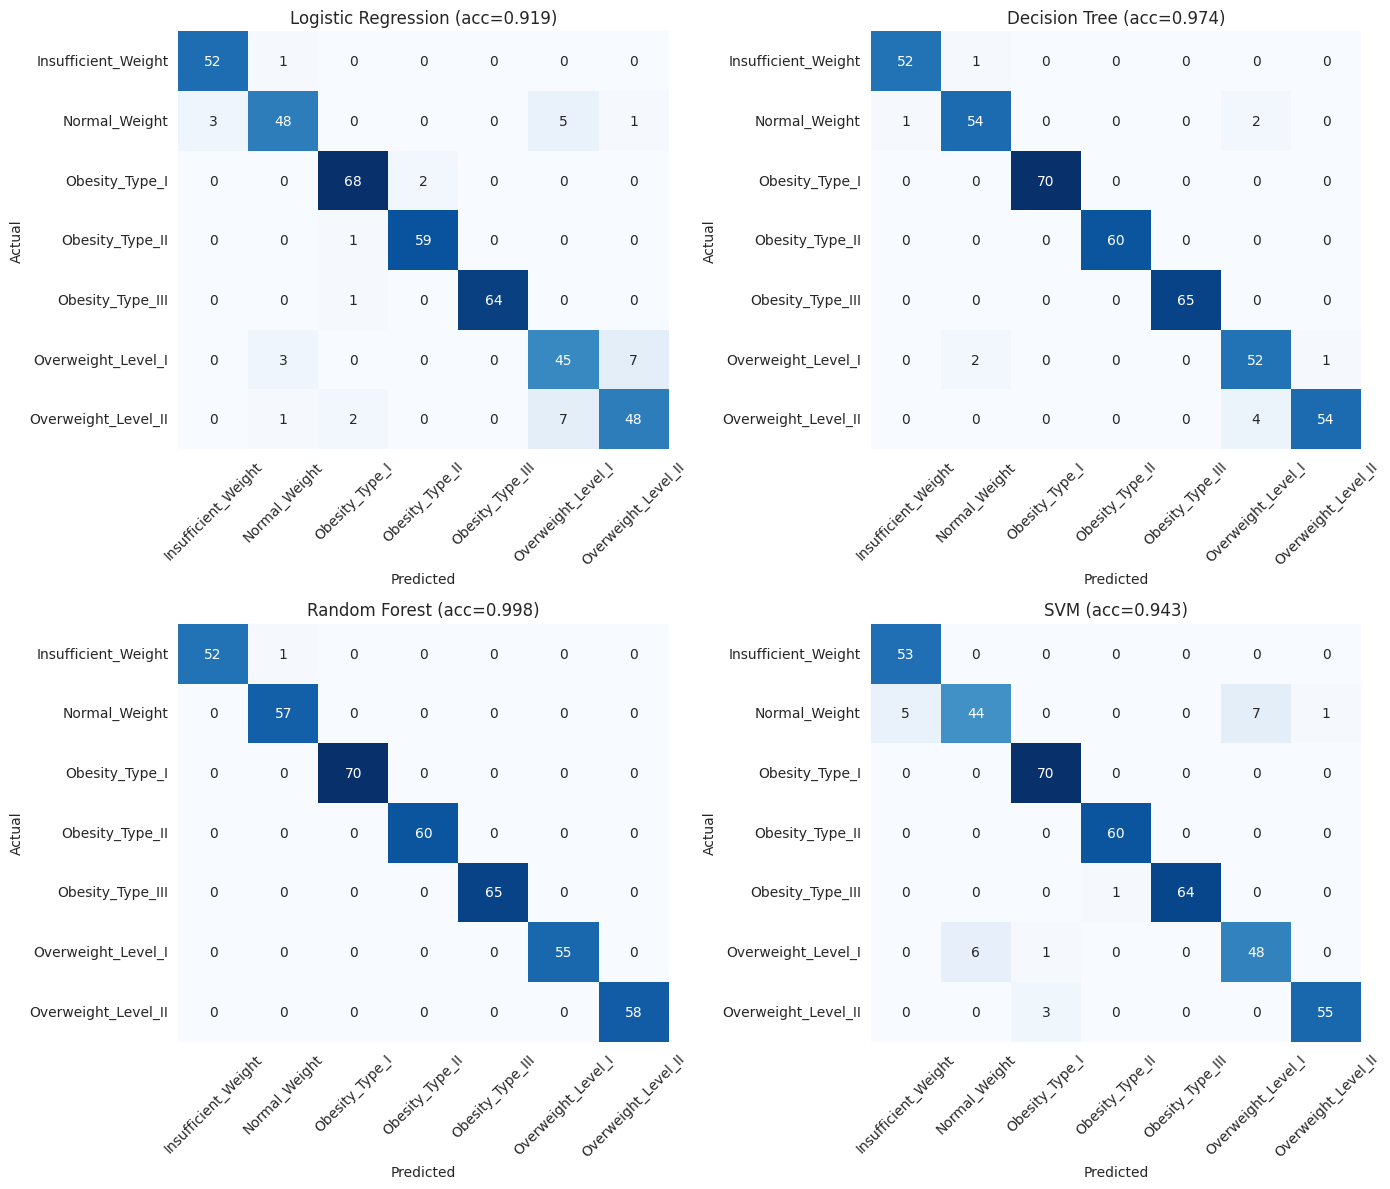

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for ax, name in zip(axes, results.keys()):
    cm = confusion_matrix(y_test, results[name]["preds"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=ax, cbar=False)
    ax.set_title(f"{name} (acc={results[name]['accuracy']:.3f})")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


## 8. Feature Importance (Random Forest)

Random Forest gives a direct, interpretable measure of which factors drive the obesity-level prediction — useful for the business-oriented recommendations later.


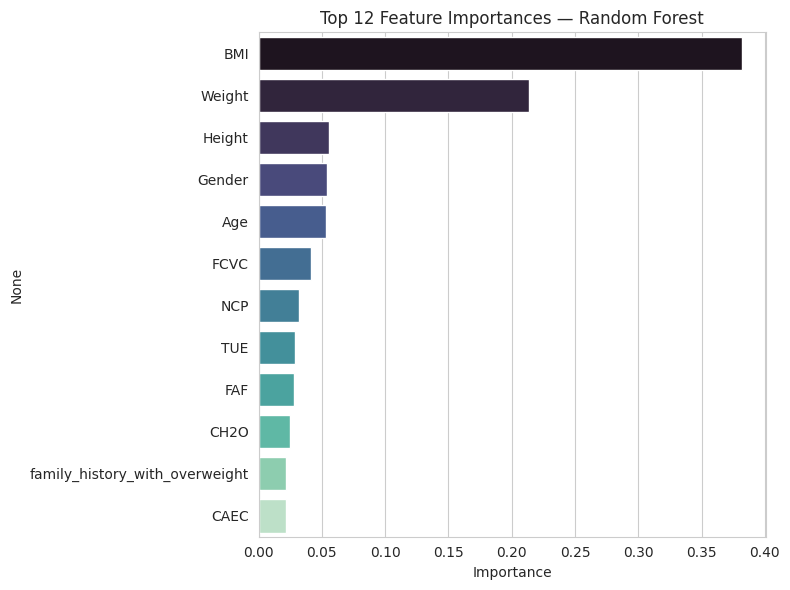

In [25]:
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
top12 = importances.head(12)
sns.barplot(x=top12.values, y=top12.index, hue=top12.index, palette="mako", legend=False)
plt.title("Top 12 Feature Importances — Random Forest")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()



## 9. Summary Table for the Dashboard / Report

Exporting a compact results table that can be dropped straight into the Power BI / Tableau dashboard or the final report.


In [28]:
summary_export = acc_df.copy()
summary_export.to_csv("model_accuracy_summary.csv", index=False)

feat_export = importances.reset_index()
feat_export.columns = ["Feature", "Importance"]
feat_export.to_csv("feature_importance_summary.csv", index=False)

print("Saved: model_accuracy_summary.csv, feature_importance_summary.csv")
summary_export

from google.colab import files
files.download("model_accuracy_summary.csv")
files.download("feature_importance_summary.csv")

Saved: model_accuracy_summary.csv, feature_importance_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>